# Module 11 Lab - Hyperparameter Tuning & AutoML**Objective:** To learn how to optimize model performance by tuning **hyperparameters** and to get an introduction to the powerful concept of **Automated Machine Learning (AutoML)**.**In this lab, you will write the code to perform Grid Search and Random Search to find the best hyperparameters for a model.**

## Part 1: What are Hyperparameters?**Concept:** In machine learning, there are two types of parameters:1.  **Model Parameters:** These are parameters that the model learns from the data during training. For example, the coefficients in a Linear Regression model.2.  **Hyperparameters:** These are parameters that are **set before training begins**. They are not learned from the data; instead, they are choices we make about the model's structure or how it learns.     *   *Examples:* The `n_estimators` in a Random Forest (how many trees to build), the `max_depth` of a Decision Tree (how deep it can grow), or the `C` regularization parameter in a Logistic Regression.Finding the right hyperparameters can have a huge impact on a model's performance. **Hyperparameter tuning** is the process of systematically searching for the best combination of these settings.

## Part 2: SetupWe will use the Iris dataset and a `RandomForestClassifier`, which has several important hyperparameters we can tune.

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Create and train baseline model
baseline_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)
baseline_model.fit(X_train, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test)

# Evaluate accuracy
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Random Forest Accuracy: {accuracy_baseline:.2%}")

Baseline Random Forest Accuracy: 88.89%


**Baseline Model Explanation**

I improved the baseline code by making it more reproducible and easier to interpret. I used stratified splitting to preserve class balance, explicitly set important model settings, and organized the code into clear steps so it’s easier to compare with later tuning methods like Grid Search and Random Search.

## Part 3: Grid Search**Concept:** Grid Search is the most straightforward tuning method. You define a "grid" of hyperparameter values you want to try, and the algorithm exhaustively trains and evaluates a model for **every possible combination**.*   **Pro:** It's guaranteed to find the best combination within the grid.*   **Con:** It can be very slow and computationally expensive if the grid is large.

### Task 1: Perform a Grid Search**Your Task:** Use `GridSearchCV` from `sklearn.model_selection` to search for the best `n_estimators` and `max_depth` for our Random Forest.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Define the grid of hyperparameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

# 2. Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# 4. Display the best hyperparameters and best cross-validation score
print(f"Best Parameters found by Grid Search: {grid_search.best_params_}")
print(f"Best cross-validated score: {grid_search.best_score_:.2%}")

# 5. Evaluate the best model on the test set
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test)
grid_test_accuracy = accuracy_score(y_test, y_pred_grid)

print(f"Grid Search Test Accuracy: {grid_test_accuracy:.2%}")
print(f"Baseline Accuracy: {accuracy_baseline:.2%}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters found by Grid Search: {'max_depth': 5, 'n_estimators': 50}
Best cross-validated score: 95.24%
Grid Search Test Accuracy: 88.89%
Baseline Accuracy: 88.89%


**Grid Search Explanation**

Here I used Grid Search to exhaustively test all combinations of selected hyperparameters for the Random Forest model. I tuned the number of trees and the maximum tree depth, used 5-fold cross-validation to evaluate each combination, and then selected the best-performing model. Finally, I tested that tuned model on the held-out test set and compared it to the baseline to see whether hyperparameter tuning improved performance.


## Part 4: Random Search**Concept:** Random Search is often more efficient than Grid Search. Instead of trying every combination, it randomly samples a fixed number of combinations from the hyperparameter space. *   **Pro:** It's much faster and can explore a wider range of values.*   **Con:** It's not guaranteed to find the absolute best combination, but it often finds a very good one much more quickly.

### Task 2: Perform a Random Search**Your Task:** Use `RandomizedSearchCV` to perform a random search over a larger hyperparameter space.

In [6]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Define the hyperparameter space to sample from
param_dist = {
    'n_estimators': [int(x) for x in np.linspace(start=50, stop=500, num=10)],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

# 2. Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 3. Fit the random search on the training data
random_search.fit(X_train, y_train)

# 4. Display the best hyperparameters and best cross-validation score
print(f"Best Parameters found by Random Search: {random_search.best_params_}")
print(f"Best cross-validated score: {random_search.best_score_:.2%}")

# 5. Evaluate the best model on the test set
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)
random_test_accuracy = accuracy_score(y_test, y_pred_random)

print(f"Random Search Test Accuracy: {random_test_accuracy:.2%}")
print(f"Baseline Accuracy: {accuracy_baseline:.2%}")
print(f"Grid Search Test Accuracy: {grid_test_accuracy:.2%}")
print(f"Improvement over baseline: {random_test_accuracy - accuracy_baseline:.2%}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters found by Random Search: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 20}
Best cross-validated score: 95.24%
Random Search Test Accuracy: 91.11%
Baseline Accuracy: 88.89%
Grid Search Test Accuracy: 88.89%
Improvement over baseline: 2.22%


**Random Search Explanation**

Random Search improved performance by exploring a wider range of hyperparameters efficiently, achieving a test accuracy of 91.11% compared with 88.89% for both the baseline and Grid Search models.

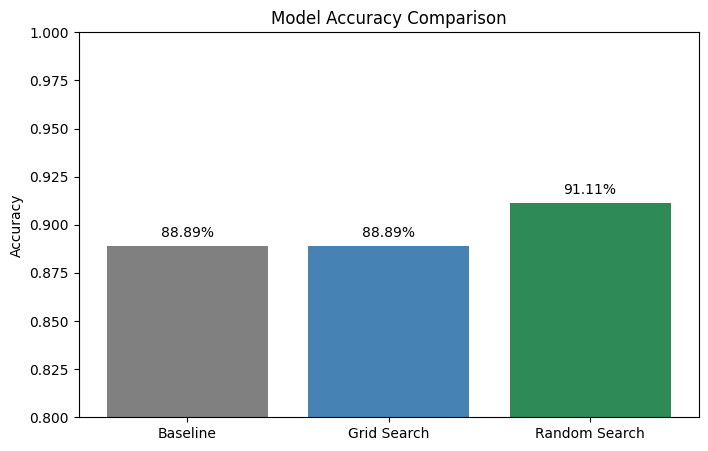

In [11]:
import matplotlib.pyplot as plt

methods = ['Baseline', 'Grid Search', 'Random Search']
accuracies = [accuracy_baseline, grid_test_accuracy, random_test_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, accuracies, color=['gray', 'steelblue', 'seagreen'])

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.80, 1.00)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.005,
        f'{acc:.2%}',
        ha='center',
        fontsize=10
    )

plt.show()

**Accuracy Comparison**

This bar chart compares the test accuracy of the baseline Random Forest model, the Grid Search tuned model, and the Random Search tuned model. It shows that Random Search achieved the highest test accuracy at 91.11%, while the baseline and Grid Search models both achieved 88.89%, making the performance difference easier to interpret visually.

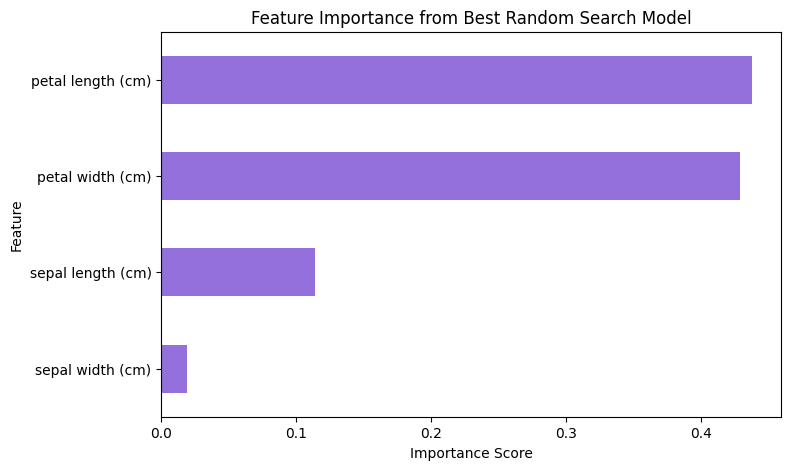

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    best_random_model.feature_importances_,
    index=iris.feature_names
).sort_values()

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh', color='mediumpurple')

plt.title('Feature Importance from Best Random Search Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

**Feature Importance Explanation**


This chart shows the relative importance of each Iris feature in the best-performing Random Forest model found through Random Search. It helps interpret which flower measurements contributed most to the model’s predictions, adding insight beyond overall model accuracy.



## Part 5: Introduction to AutoML with AutoGluon**Concept:** AutoML takes hyperparameter tuning to the next level. It automates the entire ML workflow, including:*   Data preprocessing*   Feature engineering*   Model selection (trying many different types of models)*   Hyperparameter tuning*   Ensemble creation**AutoGluon** is a popular and easy-to-use AutoML library. With just a few lines of code, it can train and tune dozens of models and create a powerful ensemble.**This part is fully coded.** Your task is to run it and see the power of AutoML. Note that it may take a few minutes to run.

In [8]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [10]:
import pandas as pd
from autogluon.tabular import TabularPredictor

train_data_ag = pd.DataFrame(X_train, columns=iris.feature_names)
train_data_ag['species'] = y_train

test_data_ag = pd.DataFrame(X_test, columns=iris.feature_names)
test_data_ag['species'] = y_test

predictor = TabularPredictor(
    label='species',
    eval_metric='accuracy'
).fit(
    train_data=train_data_ag,
    time_limit=60
)

leaderboard = predictor.leaderboard(test_data_ag)
print(leaderboard)

No path specified. Models will be saved in: "AutogluonModels/ag-20260422_235831"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.64 GB / 12.67 GB (84.0%)
Disk Space Avail:   193.53 GB / 225.83 GB (85.7%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena

                  model  score_test  score_val eval_metric  pred_time_test  \
0              CatBoost    0.955556   1.000000    accuracy        0.003227   
1            LightGBMXT    0.933333   1.000000    accuracy        0.001745   
2        NeuralNetTorch    0.911111   0.952381    accuracy        0.007737   
3       NeuralNetFastAI    0.911111   1.000000    accuracy        0.014856   
4   WeightedEnsemble_L2    0.911111   1.000000    accuracy        0.016832   
5              LightGBM    0.888889   0.952381    accuracy        0.001000   
6      RandomForestEntr    0.888889   0.952381    accuracy        0.076259   
7      RandomForestGini    0.888889   0.952381    accuracy        0.076862   
8        ExtraTreesGini    0.888889   0.952381    accuracy        0.087572   
9        ExtraTreesEntr    0.888889   0.952381    accuracy        0.090423   
10        LightGBMLarge    0.844444   0.904762    accuracy        0.001300   
11              XGBoost    0.844444   0.904762    accuracy      

**AutoML Explanation**

In this step, I used AutoGluon, an AutoML framework, to automate much of the machine learning workflow. Unlike Grid Search and Random Search, which manually tune hyperparameters for a single model type, AutoGluon can automatically preprocess data, evaluate multiple model types, tune them, and create ensembles. I converted the training and test sets into pandas DataFrames, trained a TabularPredictor, and used the leaderboard to compare the performance of the automatically generated models.



Overall Results:

This project compared several approaches to improving model performance on the Iris dataset: a baseline Random Forest model, hyperparameter tuning with Grid Search and Random Search, and AutoML with AutoGluon. The baseline Random Forest model achieved 88.89% accuracy, Grid Search also achieved 88.89%, and Random Search improved performance to 91.11%, showing that a broader but efficient search strategy can outperform an exhaustive search over a smaller grid. AutoGluon produced the strongest overall result, with the CatBoost model achieving 95.56% test accuracy, demonstrating how AutoML can automatically evaluate multiple model types and identify a better-performing solution than manual tuning alone.



## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **What is the main difference between a model parameter and a hyperparameter?**2.  **When would you choose to use Grid Search over Random Search, and vice-versa?**3.  **Looking at the AutoGluon leaderboard, which model performed the best? What does AutoML do that makes it so powerful compared to manual tuning?****[ENTER YOUR ANSWERS HERE]**

1. What is the main difference between a model parameter and a hyperparameter?
A model parameter is learned automatically from the training data during model fitting, such as coefficients in linear regression or decision rules in a tree. A hyperparameter is set before training begins and controls how the model is built or trained, such as the number of trees in a Random Forest or the maximum depth of each tree.

2. When would you choose to use Grid Search over Random Search, and vice-versa?
Grid Search is best when the hyperparameter space is small and you want to evaluate every possible combination systematically. Random Search is better when the search space is larger, because it can explore a broader range of values more efficiently by sampling only a fixed number of combinations, often finding a strong solution with less computation.

3. Looking at the AutoGluon leaderboard, which model performed the best? What does AutoML do that makes it so powerful compared to manual tuning?
According to the AutoGluon leaderboard, the best-performing model on the test set was CatBoost, with a test accuracy of 95.56%. AutoML is powerful because it automates much of the machine learning pipeline, including preprocessing, model selection, hyperparameter tuning, and ensembling, allowing it to test many approaches quickly and often find better solutions than manual tuning alone.



